<a href="https://colab.research.google.com/github/Adr1an12/analise-marketing-digital/blob/main/marketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
from google.colab import files
import pandas as pd

# Fazer upload do arquivo CSV
uploaded = files.upload()

# Carregando o arquivo CSV
base = pd.read_csv('marketing.csv')

# Exibindo as primeiras linhas
print(base.head())

Saving marketing.csv to marketing.csv
   anuncios  cliques
0       107      315
1       184      613
2        97      352
3        19       98
4       111      322


In [5]:
# Informações gerais
print(base.info())

# Estatísticas descritivas
print(base.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   anuncios  100 non-null    int64
 1   cliques   100 non-null    int64
dtypes: int64(2)
memory usage: 1.7 KB
None
         anuncios     cliques
count  100.000000  100.000000
mean   100.780000  315.320000
std     59.368491  185.166094
min      6.000000   30.000000
25%     53.750000  157.750000
50%     96.500000  310.500000
75%    154.500000  463.250000
max    196.000000  660.000000


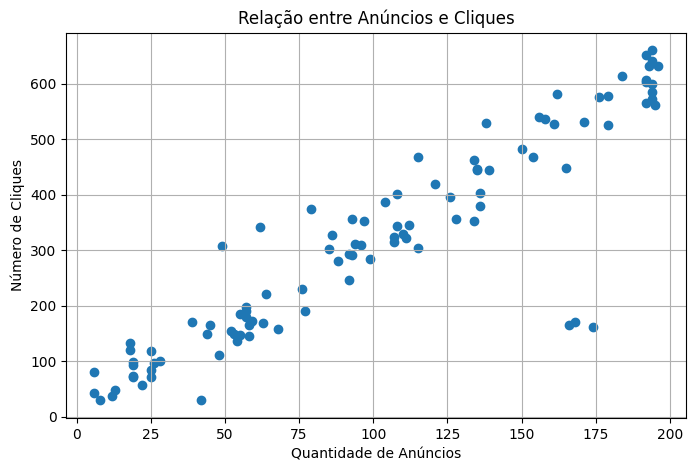

In [6]:
plt.figure(figsize=(8,5))
plt.scatter(base['anuncios'], base['cliques'])
plt.xlabel('Quantidade de Anúncios')
plt.ylabel('Número de Cliques')
plt.title('Relação entre Anúncios e Cliques')
plt.grid(True)
plt.show()

In [7]:
# Variável independente (X)
X = base[['anuncios']]

# Variável dependente (y)
y = base['cliques']

In [8]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
# Criando o modelo
modelo = LinearRegression()

# Treinando
modelo.fit(X_treino, y_treino)

LinearRegression()

In [10]:
# Previsões
previsoes = modelo.predict(X_teste)

# Comparando valores reais e previstos
resultado = pd.DataFrame({
    'Real': y_teste,
    'Previsto': previsoes
})

print(resultado.head())

    Real    Previsto
83   120   79.775503
53   221  211.552492
70   402  337.600048
45   186  185.770038
44   444  414.947412


In [11]:
# Coeficiente de determinação (R²)
r2 = r2_score(y_teste, previsoes)

# Erro quadrático médio
mse = mean_squared_error(y_teste, previsoes)

print(f'R²: {r2:.4f}')
print(f'MSE: {mse:.4f}')

R²: 0.6199
MSE: 10047.9986


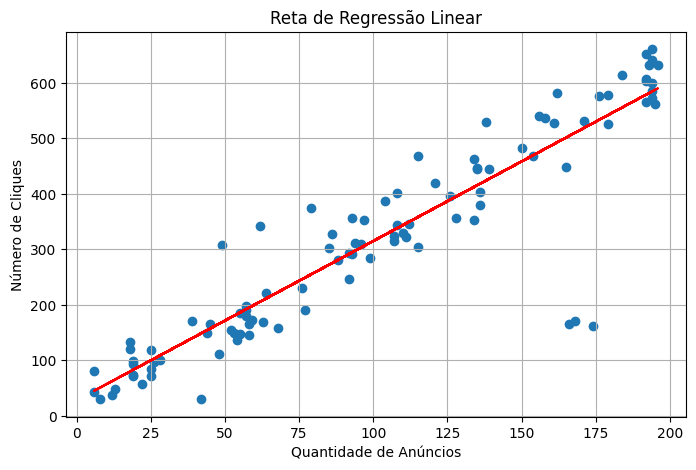

In [12]:
plt.figure(figsize=(8,5))
plt.scatter(X, y)
plt.plot(X, modelo.predict(X), color='red')
plt.xlabel('Quantidade de Anúncios')
plt.ylabel('Número de Cliques')
plt.title('Reta de Regressão Linear')
plt.grid(True)
plt.show()

In [13]:
# Exemplo de previsão
novo_valor = [[150]]
previsao = modelo.predict(novo_valor)

print(f'Quantidade prevista de cliques: {previsao[0]:.2f}')

Quantidade prevista de cliques: 457.92


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
